#**Make list of fastq files for generating manifest**

In [ ]:
# create a list of R1 fastq file paths and subsequently use it to create qiime2 manifest
# For PE reads, on the manifest sheet, duplicate the R1 column and substitute R2
# details or simply create and use a list of R2 fastq file paths
find /path-to-sequences/fastq-files/ -type f -name "*R1_001.fastq.gz" | sort > manifest.txt

#**Import data into qiime 2**

In [ ]:
#!/bin/bash
#SBATCH -N 1
#SBATCH -J import-kenya-gambiae-16S
#SBATCH -p htc
#SBATCH -q public
#SBATCH -t 0-01:60:00 # time in d-hh:mm:ss
#SBATCH -c 16
#SBATCH -o /path-to-data/import-data-out
#SBATCH -e /path-to-data/import-data-error
#SBATCH --mail-type=ALL
#SBATCH --export=NONE

# load qiime2
module purge #always a good idea
module load mamba/latest
source activate qiime2-amplicon-2025.7

# change into analysis directory
cd /path-to-data

# import the raw fastq files into qiime2 using the generated manifest
qiime tools import \
  --type 'SampleData[PairedEndSequencesWithQuality]' \
  --input-path manifest.txt \
  --output-path demux.qza \
  --input-format PairedEndFastqManifestPhred33V2

# visualiza outputs
qiime demux summarize \
  --i-data demux.qza \
  --o-visualization demux.qzv

#**Inspect demultiplexed read quality and check for adapters**

**Quality plots of demultiplexed sequencing reads**

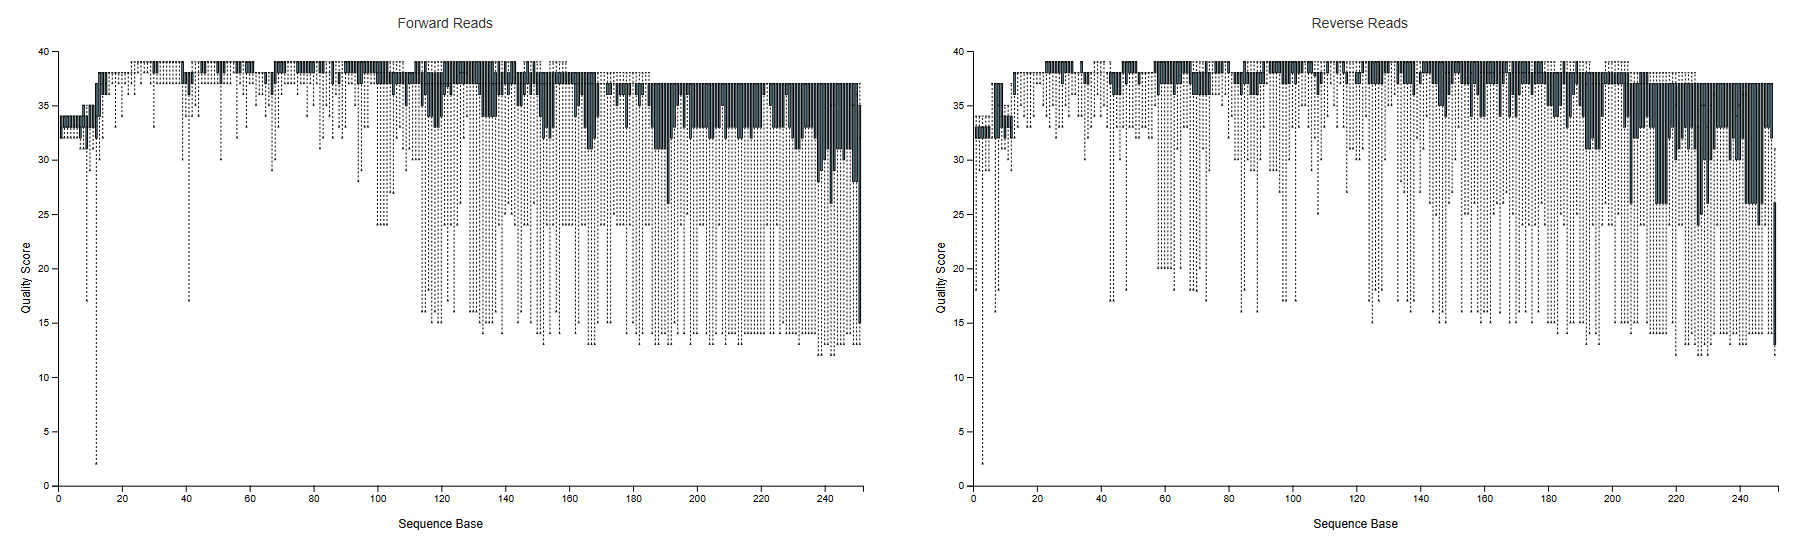

In [ ]:
# # inspect outputs of forward and reverse reads for expected primers/adapters
zcat /path-to-sequences/*R1*.fastq.gz | awk 'NR%4==2' | head -20
zcat /path-to-sequences/*R2*.fastq.gz | awk 'NR%4==2' | head -20

# ---
# inspection outcomes
# ---
# adapters are still appended at the 5' end of reads, starting at nt #1.

# ---
# adapter trimming and denoising steps to consider based on inspection outcomes
# ---
# (a) trim adapter sequences i.e. degenrate 341f -805r using q2 cutadapt plugin
# (b) clip the first n length of each read either using q2 cutadapt plugin or directly in
# dada2. Where n=number of nt in corresponding adapter

#**Denoising**

**(a) trim adapter using q2 cutadapt plugin:**
resulted in a some reads ~10% not being trimmed. Outputs were of mixed quality for downstream analysis. Subsequent dada2 denoising using these outputs resulted in >90% of reads being dropped

**(b) clip the first n length of each read either using q2 cutadapt plugin or directly in dada2:** Where n=number of nt in corresponding adapter. <br>
dada2 outputs using either clipping option were comparable, but clipping directly in dada2 fared slightly better

Used dada2 adapter clipping+denoising outputs for downstream analysis.

In [ ]:
#!/bin/bash
#SBATCH -N 1
#SBATCH -J dada2-denoise
#SBATCH -p htc
#SBATCH -q public
#SBATCH -t 0-03:59:00 # time in d-hh:mm:ss
#SBATCH -c 32
#SBATCH --mem 0
#SBATCH -o /path-to-data/dada2-out
#SBATCH -e /path-to-data/dada2-error
#SBATCH --mail-type=ALL
#SBATCH --export=NONE

# load qiime2
module purge #always a good idea
module load mamba/latest
source activate qiime2-amplicon-2025.7

# change into analysis directory
cd /path-to-data

# clip adapters using q2 dada2 plugin and denoise
# denoise data based on the parameters indicated below
qiime dada2 denoise-paired \
  --i-demultiplexed-seqs demux.qza \
  --p-trunc-len-f 0 \
  --p-trunc-len-r 0 \
  --p-trim-left-f 17 \
  --p-trim-left-r 21 \
  --p-min-fold-parent-over-abundance 8 \
  --p-n-threads 0 \
  --o-representative-sequences rep-seqs.qza \
  --o-table table.qza \
  --o-denoising-stats dada2-stats.qza

# visualize denoising stats
qiime metadata tabulate \
  --m-input-file dada2-stats.qza \
  --o-visualization dada2-stats.qzv

# summarize table
qiime feature-table summarize \
  --i-table table.qza \
  --o-visualization summarized-table.qzv

# generate feaure table summary
qiime feature-table summarize \
  --i-table table.qza \
  --m-sample-metadata-file metadata.txt \
  --o-visualization feature-summary.qzv

# generate feature data summary
qiime feature-table tabulate-seqs \
  --i-data rep-seqs.qza \
  --o-visualization rep-seqs.qzv


#**Filter negative control features from reads and subsequently filter data by location to retain only unpublished data (Kitabisi data)**

In [ ]:
#!/bin/bash
#SBATCH -N 1
#SBATCH -J decontam
#SBATCH -p htc
#SBATCH -q public
#SBATCH -t 0-03:59:00 # time in d-hh:mm:ss
#SBATCH -c 32
#SBATCH --mem 100G
#SBATCH -o /path-to-data/decontam-out
#SBATCH -e /path-to-data/decontam-error
#SBATCH --mail-type=ALL
#SBATCH --export=NONE

# load qiime2
module purge #always a good idea
module load mamba/latest
source activate qiime2-amplicon-2025.7

# change into analysis directory
cd /path-to-data

# identify contamination using both frequency and prevalence
qiime quality-control decontam-identify \
  --i-table table.qza \
  --m-metadata-file metadata.txt \
  --p-method combined \
  --p-freq-concentration-column dna-conc \
  --p-prev-control-column sample-type \
  --p-prev-control-indicator control \
  --o-decontam-scores decontam-scores.qza

# inspect contamination by visualizing decontamination scores
qiime quality-control decontam-score-viz \
  --i-decontam-scores first:decontam-scores.qza \
  --i-table first:table.qza \
  --i-rep-seqs rep-seqs.qza \
  --p-threshold 0.1 \
  --p-no-weighted \
  --p-bin-size 0.02 \
  --o-visualization decontam-scores.qzv

# filter out contaminants based on contamination threshold identified above
# filter features
qiime feature-table filter-features \
  --i-table table.qza \
  --m-metadata-file decontam-scores.qza \
  --p-where '[p]>0.1 OR [p] IS NULL' \
  --o-filtered-table decontam-table.qza

# also filter contamination from representative sequences
qiime feature-table filter-seqs \
  --i-data rep-seqs.qza \
  --i-table decontam-table.qza \
  --o-filtered-data decontam-rep-seqs.qza

# filter to retain only Kitabisi (unpublished) data
qiime feature-table filter-samples \
  --i-table decontam-table.qza \
  --m-metadata-file metadata.txt \
  --p-where "[village]='Turukuyi', 'Kisian'" \
  --p-exclude-ids \
  --o-filtered-table table-kitabisi.qza

# vsualize filtered table
qiime metadata tabulate \
  --m-input-file table-kitabisi.qza \
  --o-visualization table-kitabisi.qzv

#**Taxonomic annotation and visualization via barplots and heatmap** <br>
This was performed on post decontam outputs fruther fitered to only retain features that were at least 3.49-e3% abundant in at least 8% of samples. <br>
Reads that mapped to d__Eukaryota, e.g. mitochondria and chloroplast, were also removed

In [ ]:
#!/bin/bash
#SBATCH -N 1
#SBATCH -J heatmap
#SBATCH -p htc
#SBATCH -q public
#SBATCH -t 0-03:59:00 # time in d-hh:mm:ss
#SBATCH -c 32
#SBATCH --mem 200G
#SBATCH -o /path-to-data/heatmap-out
#SBATCH -e /path-to-data/heatmap-error
#SBATCH --mail-type=ALL
#SBATCH --export=NONE

# load qiime2
module purge #always a good idea
module load mamba/latest
source activate qiime2-amplicon-2025.7

# change into analysis directory
cd /path-to-data

# Filter table to retain only features that were present in at least 8% of samples (n=69).
# Feature relative abundance threshold was set to at least 3.49-e3% of total feature frequency (n=1,430,859)
qiime feature-table filter-features-conditionally \
    --i-table table-kitabisi.qza \
    --p-abundance 0.0000349 \
    --p-prevalence 0.08 \
    --o-filtered-table table-kitabisi-low-freq-rmvd.qza

# vsualize filtered table
qiime metadata tabulate \
  --m-input-file table-kitabisi-low-freq-rmvd.qza \
  --o-visualization table-kitabisi-low-freq-rmvd.qzv

# run taxonomic classification on kitabisi rep seqs using
# using the pre tairaned Naive Bayes SILVA138.2_SSURef_NR99_uniform_classifier for QIIME 2
# https://www.arb-silva.de/current-release/QIIME2/2025.7/SSU/full-length/uniform
qiime feature-classifier classify-sklearn \
  --i-classifier SILVA138.2_SSURef_NR99_uniform_classifier_full-length.qza \
  --p-n-jobs 0 \
  --i-reads decontam-rep-seqs.qza \
  --o-classification taxonomy.qza

# filter out Eukaryota from representative sequences
qiime taxa filter-seqs \
  --i-sequences rep-seqs-kitabisi.qza \
  --i-taxonomy taxonomy.qza \
  --p-exclude d__Eukaryota \
  --o-filtered-sequences rep-seqs-kitabisi-euk-rmvd.qza

# then retain feature table data in non Eukaryota rep seqs
qiime feature-table filter-seqs \
    --i-data rep-seqs-kitabisi-euk-rmvd.qza \
    --i-table table-kitabisi-low-freq-rmvd.qza \
    --o-filtered-data rep-seqs-kitabisi-fully-filtered.qza

# finally retain filtered info in the seq table
qiime feature-table filter-features \
  --i-table table-kitabisi-low-freq-rmvd.qza \
  --m-metadata-file rep-seqs-kitabisi-fully-filtered.qza \
  --o-filtered-table table-kitabisi-fully-filtered.qza

# after running the above filter-seqs and filter-features steps, I learned that
# these earlier versions of qiime 2 allow taxonomic filtering of feature tables
# using the command: qiime taxa filter-table

# vsualize filtered table
qiime metadata tabulate \
  --m-input-file table-kitabisi-fully-filtered.qza \
  --o-visualization table-kitabisi-fully-filtered.qzv

# generate feature data summary
qiime feature-table tabulate-seqs \
  --i-data rep-seqs-kitabisi-fully-filtered.qza \
  --o-visualization rep-seqs-kitabisi-fully-filtered.qzv

# run taxonomic classification on filtered seqs
qiime feature-classifier classify-sklearn \
  --i-classifier SILVA138.2_SSURef_NR99_uniform_classifier_full-length.qza \
  --p-n-jobs 0 \
  --i-reads rep-seqs-kitabisi-fully-filtered.qza \
  --o-classification taxonomy-kitabisi-euk-rmvd.qza

# tabulate and visualize updated taxonomy
qiime metadata tabulate \
  --m-input-file taxonomy-kitabisi-euk-rmvd.qza \
  --o-visualization taxonomy-kitabisi-euk-rmvd.qzv

# Collapse table to one taxonomic level (genus)
 qiime taxa collapse \
    --i-table table-kitabisi-fully-filtered.qza \
    --i-taxonomy taxonomy-kitabisi-euk-rmvd.qza \
    --p-level 6 \
    --o-collapsed-table collapsed-taxa-table-kitabisi.qza

# export content of collapsed table artifact to shorten taxa names
qiime tools export \
--input-path collapsed-taxa-table-kitabisi.qza \
--output-path exported-collapsed-kitabisi-table

# then convert biom to tsv and shorten taxa names
biom convert \
  -i exported-collapsed-kitabisi-table/feature-table.biom \
  -o exported-collapsed-kitabisi-table/feature-table.tsv \
  --to-tsv

# shorten taxa names and reimport into qiime 2
# first reconvert to biom
biom convert \
  -i exported-collapsed-kitabisi-table/feature-table-short-taxa-names.txt \
  -o exported-collapsed-kitabisi-table/feature-table-short-taxa-names.biom \
  --table-type="OTU table" \
  --to-hdf5

# then import revised biom into qiime 2
qiime tools import \
  --input-path exported-collapsed-kitabisi-table/feature-table-short-taxa-names.biom \
  --type 'FeatureTable[Frequency]' \
  --input-format BIOMV210Format \
  --output-path kitabisi-table-short-taxa-names.qza

# generate heatmap
  qiime feature-table heatmap \
    --i-table kitabisi-table-short-taxa-names.qza \
    --m-sample-metadata-file metadata.txt \
    --m-sample-metadata-column phenotype-intensity \
    --p-cluster 'features' \
    --p-color-scheme 'Blues' \
    --p-metric braycurtis \
    --o-visualization heatmap-kitabisi.qzv